In [1]:
# ===========================================================================
# RAG-Ex Full Evaluation — Arabic Legal RAG
# ===========================================================================
# Perturbation level: SENTENCE (not document).
# Each source text is split into sentences. Each sentence is one feature.
# This works correctly regardless of whether a sample has 1, 2, or 3 sources.
#
# Upload to /content/:
#   1. ragex_framework/ (unzip ragex_framework_v5.zip)
#   2. generated_answers.jsonl
# ===========================================================================




In [2]:
!unzip -q ragex_framework_v5.zip

In [3]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q sentence-transformers openai matplotlib seaborn arabic-reshaper python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 28.1 MB/s eta 0:00:00


Loading BGE-M3 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Streaming output truncated to the last 5000 lines.
         original : 5
         perturbed: دون إخلال بالأحكام والشروط الواردة في نظام الاستثمار الأجنبي، يشترط للترخيص لمكت
       S32  score=0.878
         original : الحصول على الموافقات اللازمة للاستثمار الأجنبي؛
         perturbed: دون إخلال بالأحكام والشروط الواردة في نظام الاستثمار الأجنبي، يشترط للترخيص لمكت
       S33  score=0.310
         original : وفقاً لما تقضي به الأنظمة ذات الصلة.
         perturbed: دون إخلال بالأحكام والشروط الواردة في نظام الاستثمار الأجنبي، يشترط للترخيص لمكت
      Entity Manipulation | 33/33 done.              
    Entity Manipulation  (mean=0.523)
       S1  score=0.755
         original : [مصدر 1] نظام المحاماة -- المادة الخامسة والأربعون (BOE): دون إخلال بالأحكام وال
         perturbed: دون إخلال بالأحكام والشروط الواردة في نظام الاستثمار الأجنبي، يشترط للترخيص لمكت
       S2  score=1.000
         original : أن يكون ذا سمعة دولية متميزة في مجال مزاولة مهنة المحاماة وفق المؤشرات والتقارير
         p

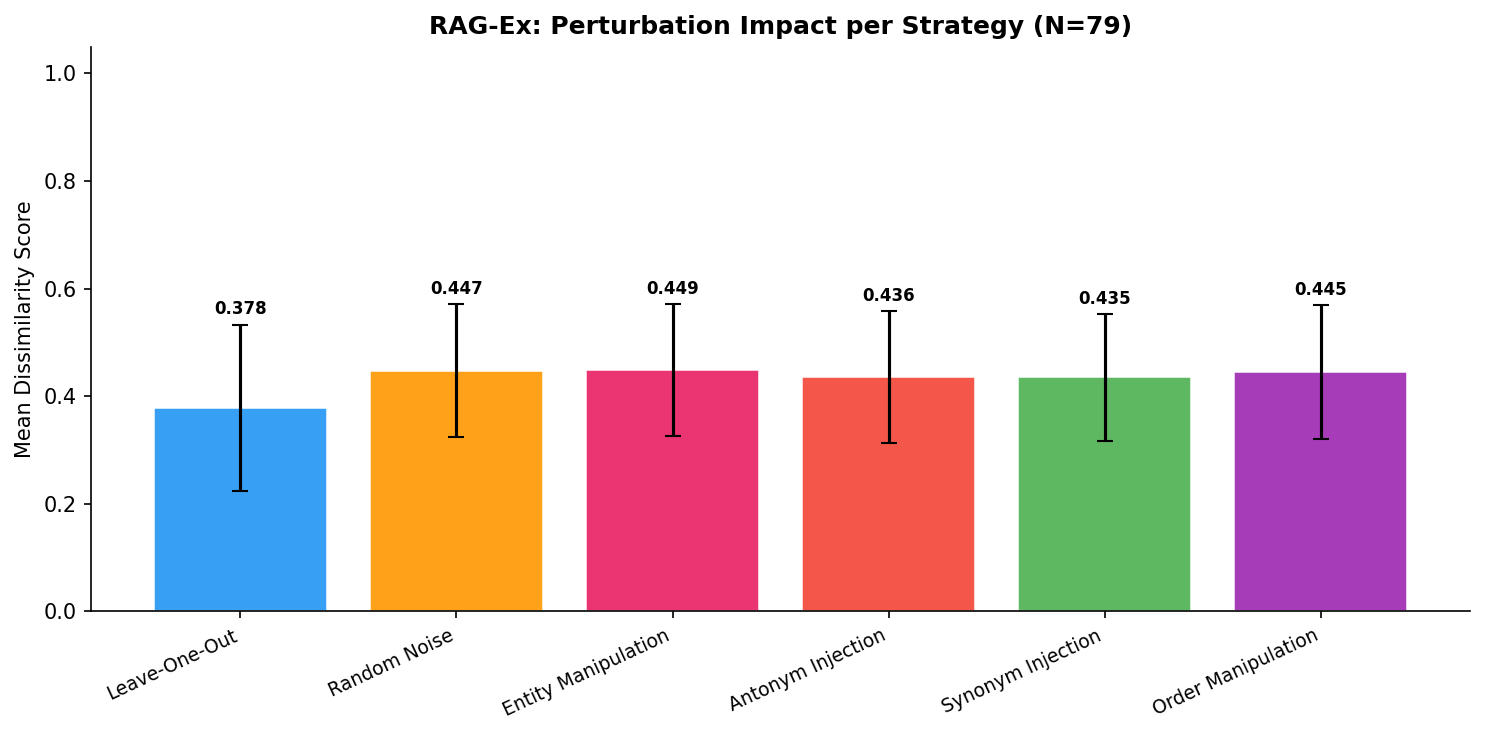

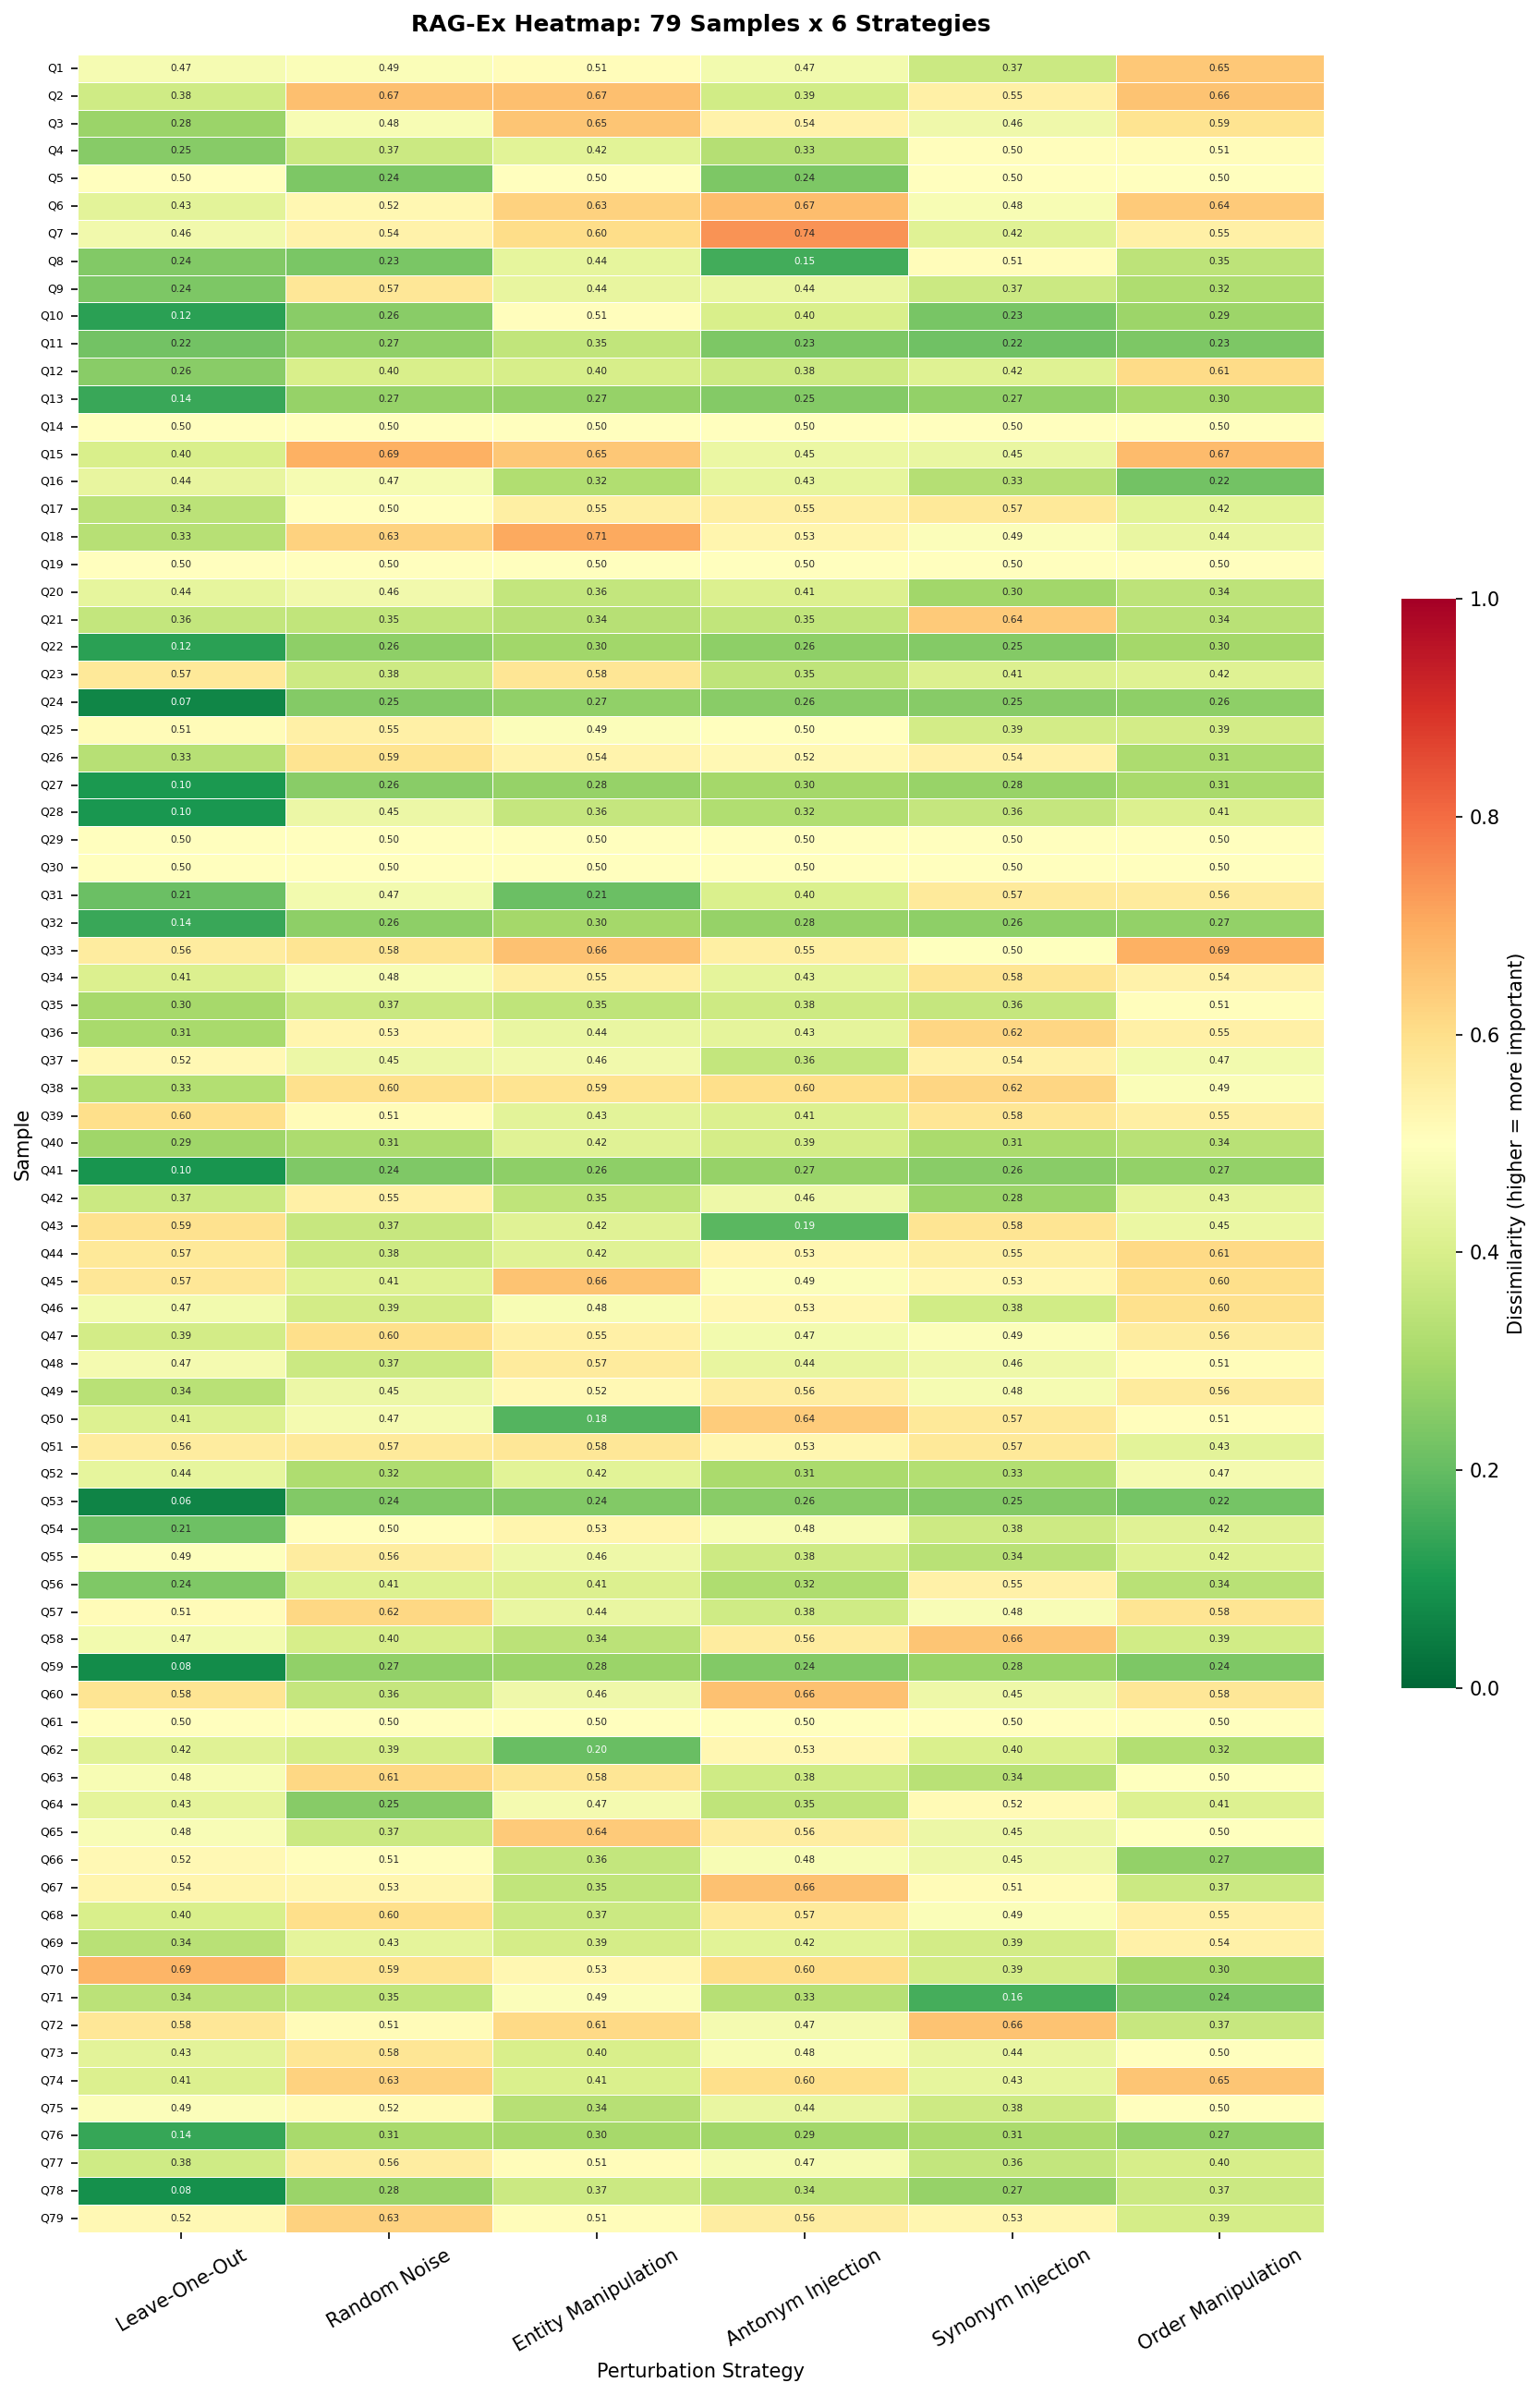

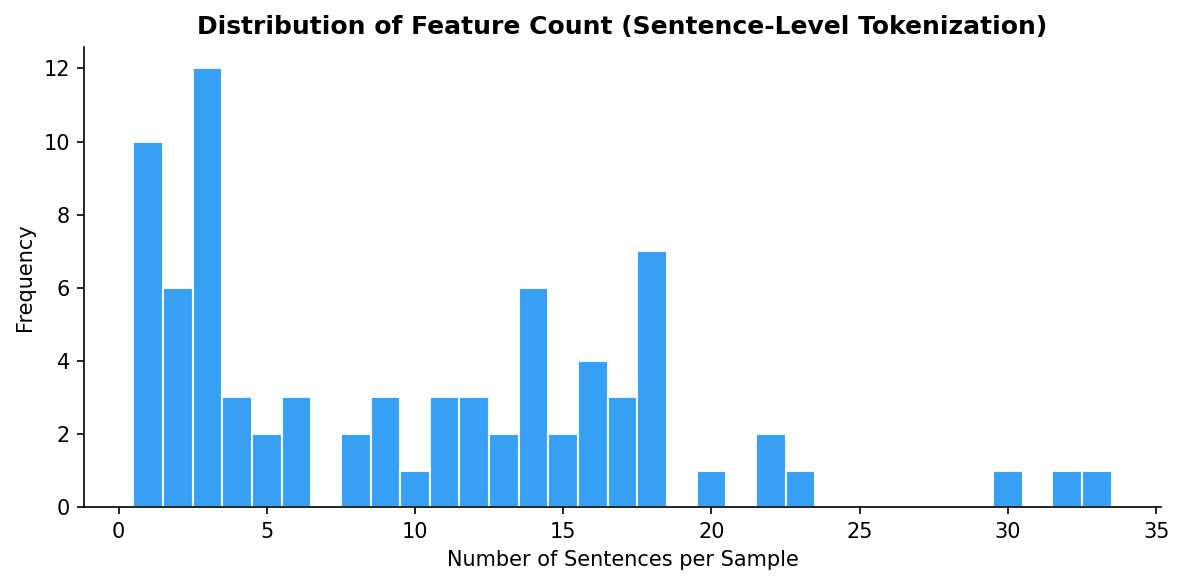

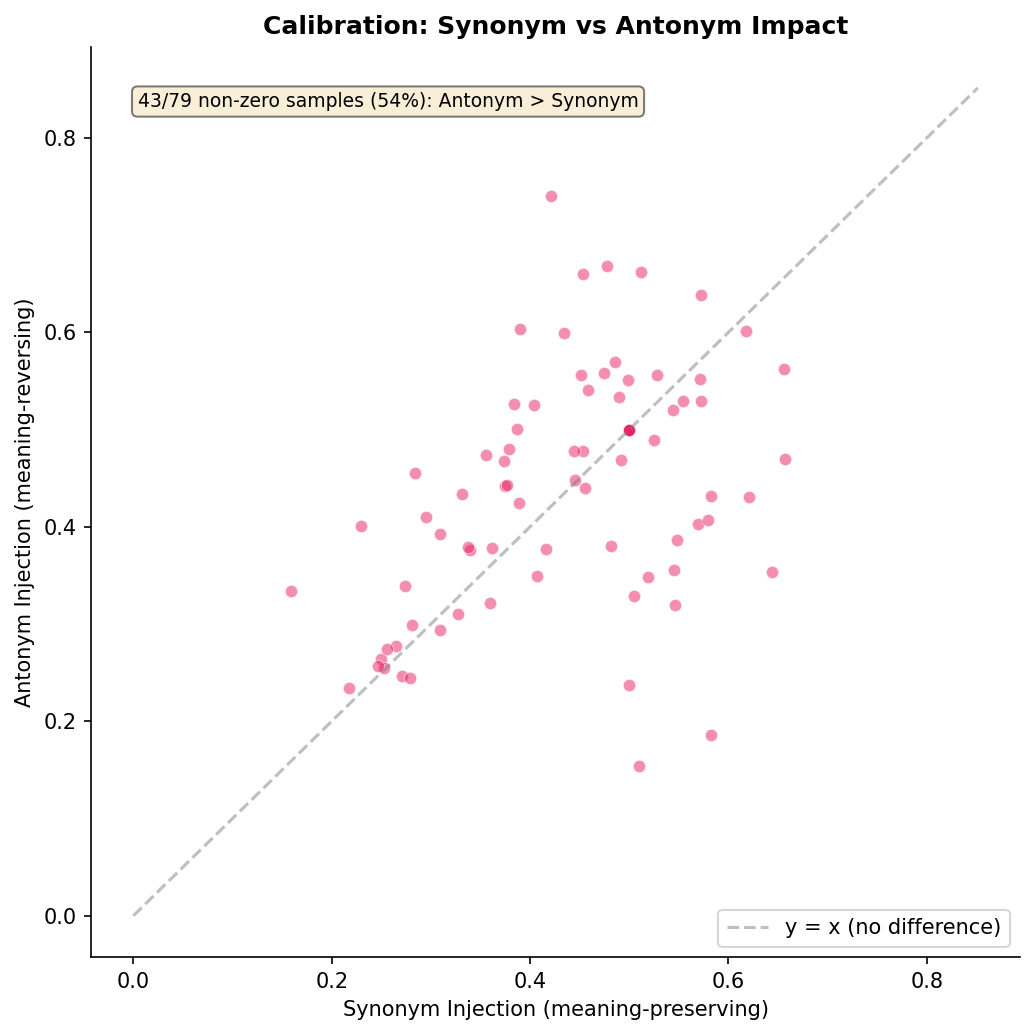

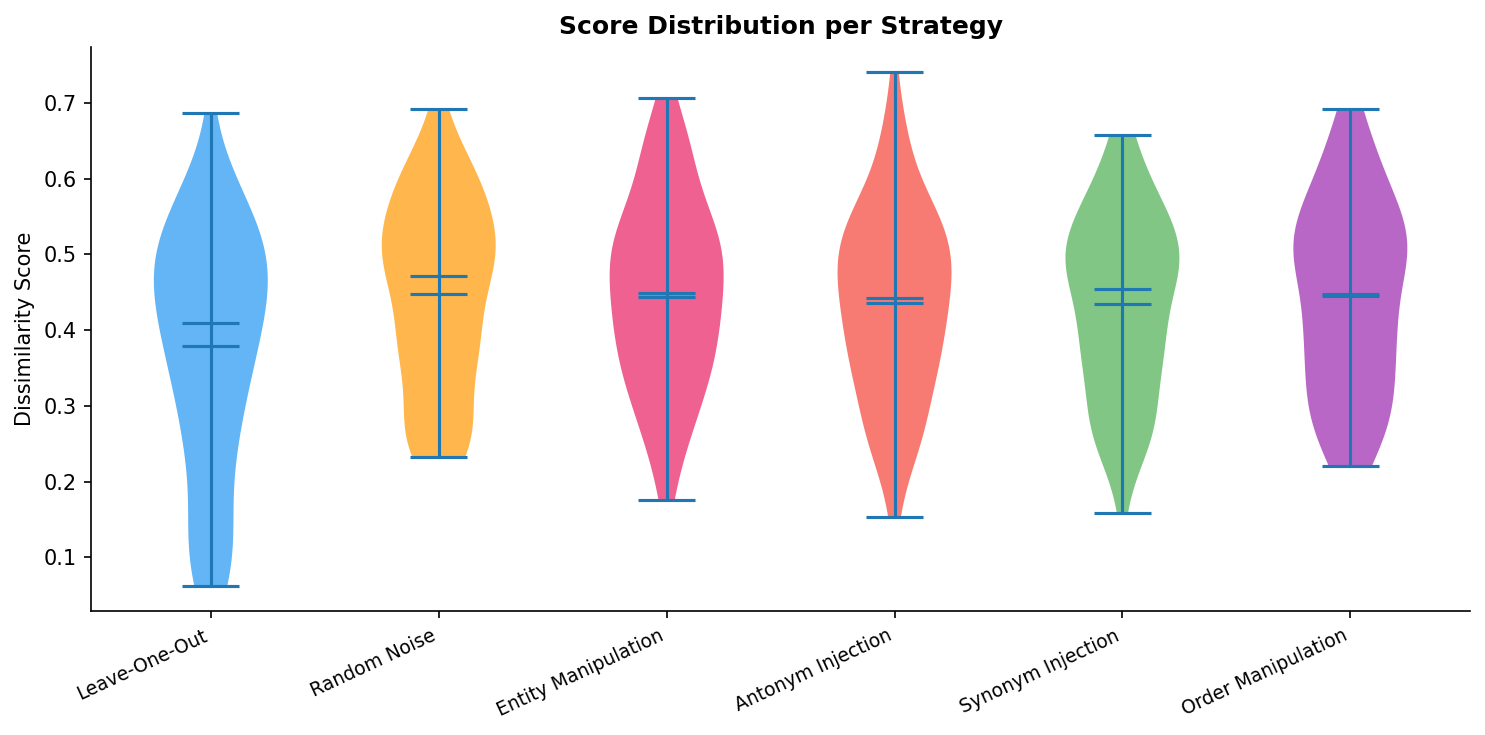

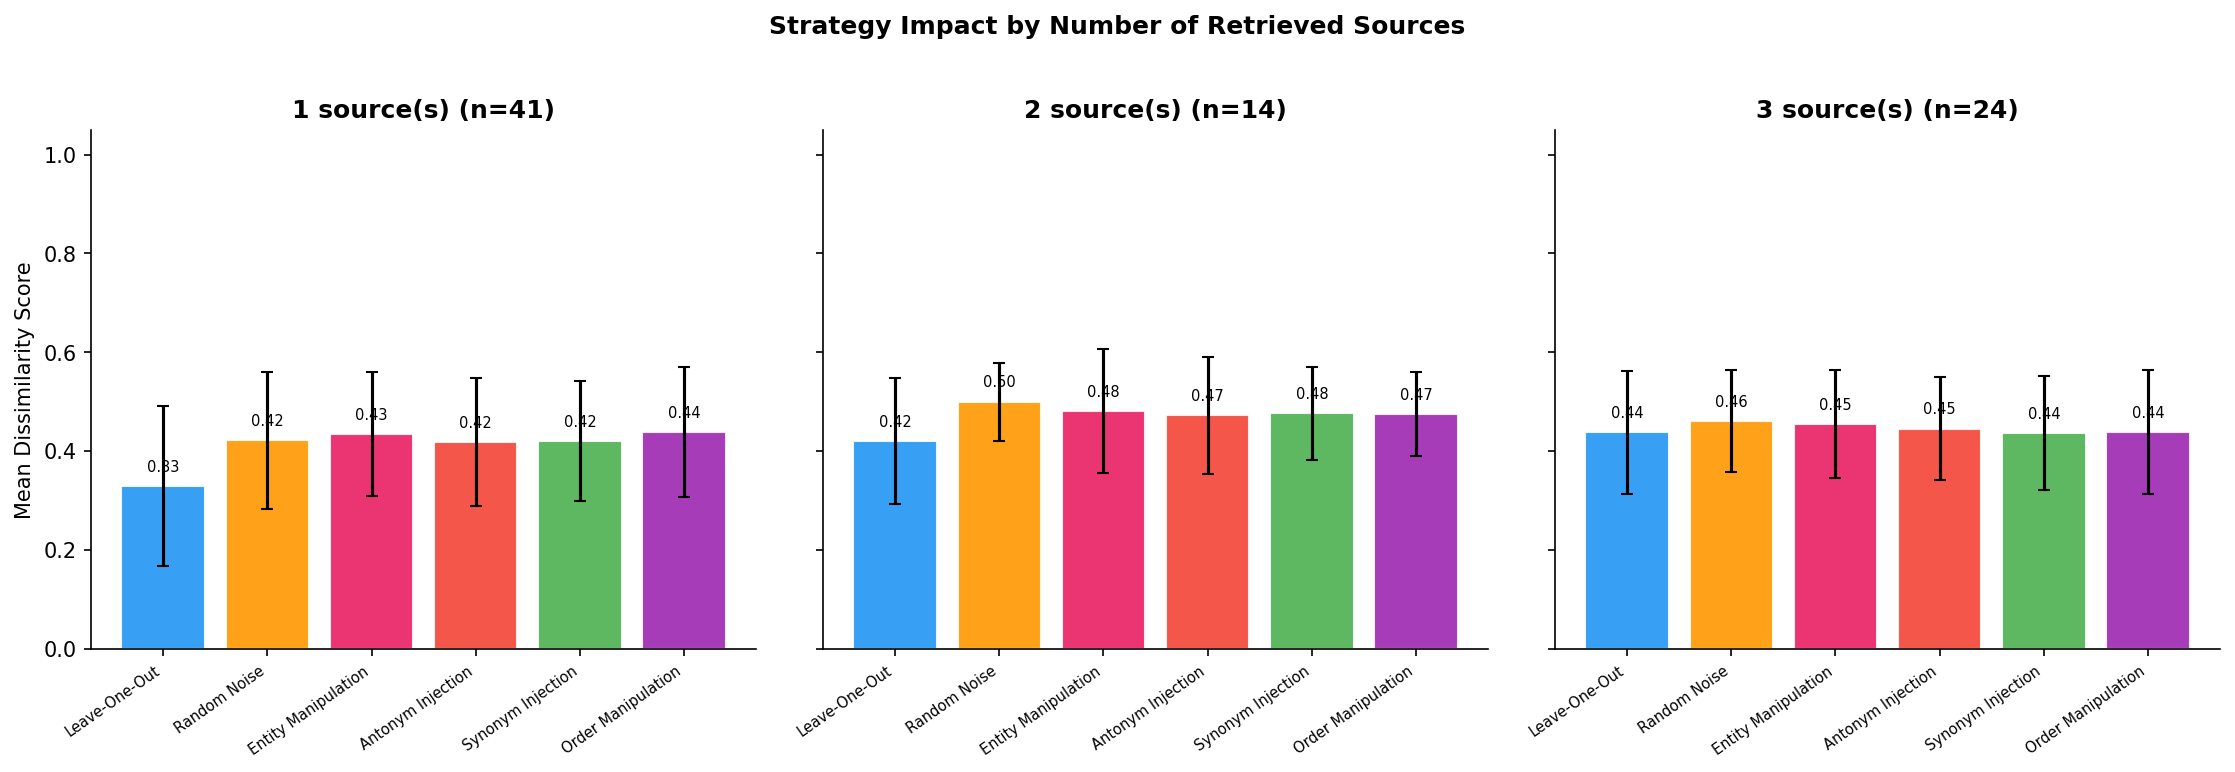

All figures saved to /content/.
  RAG-Ex Evaluation Report
  Perturbation-Based Explainability for Arabic Legal RAG

1. EXPERIMENTAL SETUP
--------------------------------------------------------------------------------

   Dataset:            79 question-answer pairs
   Source distribution: 1 source: 41, 2 sources: 14, 3 sources: 24
   Perturbation level: Sentence (each source is tokenized into sentences)
   Sentence counts:    min=1, max=33, mean=9.9
   Generator:          DeepSeek-Chat (temperature=0.7, max_tokens=500)
   Embedder:           BAAI/bge-m3
   Comparator:         LegalHybridComparator (0.75 embedding, 0.15 n-gram, 0.10 Levenshtein)
                       Leave-One-Out uses EmbeddingComparator (paper best config, S4.1)

   Perturbation is performed at sentence level rather than document level.
   This is critical because 41/79 samples (52%) have only
   one retrieved source. Document-level perturbation of a single source
   produces only one feature, making min-max norma

In [4]:


# %% Cell 2: DeepSeek + Embedder

import os, re, json, time, sys
import numpy as np
from collections import Counter
from openai import OpenAI

os.environ["DEEPSEEK_API_KEY"] = "sk-8f69cff572464a92bb2277cd50309980"
deepseek_client = OpenAI(
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url="https://api.deepseek.com"
)

from sentence_transformers import SentenceTransformer
print("Loading BGE-M3 ...")
embedder = SentenceTransformer("BAAI/bge-m3")
embedder.max_seq_length = 256
print("Embedder ready.")


# %% Cell 3: Import framework

if "/content" not in sys.path:
    sys.path.insert(0, "/content")

from ragex_framework.dto import ExplanationGranularity
from ragex_framework.modules.tokenizer.arabic_legal_tokenizer import ArabicLegalTokenizer
from ragex_framework.modules.comparator.embedding_comparator import EmbeddingComparator
from ragex_framework.modules.comparator.legal_hybrid_comparator import LegalHybridComparator
from ragex_framework.modules.perturber.leave_one_out_perturber import LeaveOneOutPerturber
from ragex_framework.modules.perturber.llm_based_perturber import (
    RandomNoisePerturber, EntityManipulationPerturber,
    AntonymInjectionPerturber, SynonymInjectionPerturber,
)
from ragex_framework.modules.perturber.reorder_perturber import OrderManipulationPerturber
print("RAG-Ex framework imported.")


# %% Cell 4: Load data + helpers

JSONL_PATH = "/content/generated_answers.jsonl"
with open(JSONL_PATH, "r", encoding="utf-8") as f:
    ALL_SAMPLES = [json.loads(line) for line in f if line.strip()]
print(f"Loaded {len(ALL_SAMPLES)} samples.")

src_dist = Counter(len(s["top_sources"]) for s in ALL_SAMPLES)
print(f"Source distribution: {dict(sorted(src_dist.items()))}")

STRATEGY_NAMES = [
    "Leave-One-Out",
    "Random Noise",
    "Entity Manipulation",
    "Antonym Injection",
    "Synonym Injection",
    "Order Manipulation",
]

tokenizer = ArabicLegalTokenizer()


def strip_sources(answer):
    if not answer:
        return ""
    for m in ("**المصادر:**", "**المصادر**:", "المصادر:",
              "**المراجع:**", "المراجع:", "**استنادًا إلى:**"):
        if m in answer:
            return answer.split(m)[0].strip()
    return answer.strip()


def build_context_block(sources):
    parts = []
    for i, s in enumerate(sources, 1):
        parts.append(
            f"[مصدر {i}] {s['law']} -- {s['article']} "
            f"({s['source'].upper()}):\n{s['text']}"
        )
    return "\n\n".join(parts)


def generate_answer(question, context_block):
    prompt = f"""أنت مساعد ذكي متخصص في القانون السعودي.

السياق:
{context_block}

السؤال:
{question}

الإجابة:"""
    try:
        r = deepseek_client.chat.completions.create(
            model="deepseek-chat",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.7,
            max_tokens=500,
        )
        return strip_sources(r.choices[0].message.content.strip())
    except Exception as e:
        print(f"      DeepSeek error: {type(e).__name__}: {e}")
        return ""


def _nws(t):
    return re.sub(r"\s+", " ", (t or "")).strip()


print("Helpers ready.")

# -- Google Drive auto-save setup --
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_DIR = "/content/drive/MyDrive/ragex_results"
os.makedirs(DRIVE_DIR, exist_ok=True)
LOCAL_PATH  = "/content/ragex_full_output.json"
DRIVE_PATH  = f"{DRIVE_DIR}/ragex_full_output.json"
CHECKPOINT  = f"{DRIVE_DIR}/ragex_checkpoint.json"
print(f"Auto-save enabled: {DRIVE_DIR}")



# %% Cell 5: Run all 79 samples x 6 strategies (sentence-level)
# ===========================================================================
# For each sample:
#   1. Build context from top_sources (1, 2, or 3 sources)
#   2. Tokenize the full context into SENTENCES (not documents)
#   3. Each sentence is one feature
#   4. For each strategy: perturb each sentence, regenerate, compare
#
# This ensures that even single-source samples produce multiple features
# (a single source typically contains 2-5 sentences), giving meaningful
# perturbation scores across all strategies.
# ===========================================================================

all_output = []
total_t0 = time.time()

for si, sample in enumerate(ALL_SAMPLES):

    question      = sample["question"]
    sources       = sample["top_sources"]
    context_block = build_context_block(sources)
    baseline      = strip_sources(sample["generated_answer"])
    n_src         = len(sources)

    # Tokenize at sentence level
    sentences = tokenizer.tokenize(context_block, ExplanationGranularity.SENTENCE_LEVEL)
    n_sents = len(sentences)

    print(f"\n{'—'*80}")
    print(f"  Sample {si+1}/{len(ALL_SAMPLES)}  |  idx={sample['idx']}  |  "
          f"sources={n_src}  |  sentences={n_sents}")
    print(f"  Q: {question[:70]}")
    print(f"{'—'*80}")

    sample_record = {
        "idx":             sample["idx"],
        "question":        question,
        "baseline_answer": baseline,
        "num_sources":     n_src,
        "num_sentences":   n_sents,
        "sentences":       sentences,
        "sources": [
            {
                "rank":     s["rank"],
                "source":   s["source"],
                "law":      s["law"],
                "article":  s["article"],
                "citation": s["citation"],
                "text":     s["text"],
            }
            for s in sources
        ],
        "strategies": {},
    }

    for strat_name in STRATEGY_NAMES:

        # Instantiate perturber + comparator
        if strat_name == "Leave-One-Out":
            perturber  = LeaveOneOutPerturber()
            comparator = EmbeddingComparator(encoder=embedder)
        elif strat_name == "Random Noise":
            perturber  = RandomNoisePerturber(deepseek_client)
            comparator = LegalHybridComparator(encoder=embedder)
        elif strat_name == "Entity Manipulation":
            perturber  = EntityManipulationPerturber(deepseek_client)
            comparator = LegalHybridComparator(encoder=embedder)
        elif strat_name == "Antonym Injection":
            perturber  = AntonymInjectionPerturber(deepseek_client)
            comparator = LegalHybridComparator(encoder=embedder)
        elif strat_name == "Synonym Injection":
            perturber  = SynonymInjectionPerturber(deepseek_client)
            comparator = LegalHybridComparator(encoder=embedder)
        else:
            perturber  = OrderManipulationPerturber(seed=42)
            comparator = LegalHybridComparator(encoder=embedder)

        if hasattr(perturber, "prepare"):
            perturber.prepare(question)

        # PERTURB at sentence level
        perturbed_contexts = perturber.perturb(context_block, sentences)

        # GENERATE perturbed answers
        perturbed_answers = []
        for pi, pc in enumerate(perturbed_contexts):
            print(f"      {strat_name} | sent {pi+1}/{n_sents}", end="\r")
            pa = generate_answer(question, pc)
            perturbed_answers.append(pa)
        print(f"      {strat_name} | {n_sents}/{n_sents} done.              ")

        # COMPARE
        dissim_scores = comparator.compare(
            reference_text=baseline,
            texts=perturbed_answers,
            do_normalize_scores=True,
        )

        # Build per-sentence details
        per_sentence = []
        for si_inner in range(n_sents):
            original_sent = sentences[si_inner]

            if strat_name == "Leave-One-Out":
                perturbed_sent = "[REMOVED]"
            else:
                # Extract the perturbed version of this sentence
                pc = perturbed_contexts[si_inner]
                perturbed_sent = pc
                for sj in range(n_sents):
                    if sj != si_inner:
                        perturbed_sent = perturbed_sent.replace(sentences[sj], "")
                # Clean metadata headers
                perturbed_sent = re.sub(r'\[مصدر \d+\].*?:\n', '', perturbed_sent)
                perturbed_sent = re.sub(r'\n\s*\n+', '\n', perturbed_sent).strip()
                if not perturbed_sent:
                    perturbed_sent = "(unchanged)"

            per_sentence.append({
                "sentence_idx":     si_inner + 1,
                "original_text":    original_sent,
                "perturbed_text":   perturbed_sent,
                "perturbed_answer": perturbed_answers[si_inner],
                "score":            round(float(dissim_scores[si_inner]), 4),
            })

        sample_record["strategies"][strat_name] = {
            "scores":       [round(float(s), 4) for s in dissim_scores],
            "mean_score":   round(float(np.mean(dissim_scores)), 4),
            "per_sentence": per_sentence,
        }

        # Print
        print(f"    {strat_name}  (mean={np.mean(dissim_scores):.3f})")
        for d in per_sentence:
            print(f"       S{d['sentence_idx']}  score={d['score']:.3f}")
            print(f"         original : {_nws(d['original_text'])[:80]}")
            print(f"         perturbed: {_nws(d['perturbed_text'])[:80]}")

    all_output.append(sample_record)

    # -- Auto-save: every sample to checkpoint, every 20 to full snapshot --
    # Checkpoint: always overwrite with latest state (crash recovery)
    with open(CHECKPOINT, "w", encoding="utf-8") as _f:
        json.dump(all_output, _f, ensure_ascii=False, indent=2)

    # Snapshot every 20 samples
    if (si + 1) % 20 == 0:
        snapshot_path = f"{DRIVE_DIR}/ragex_output_first_{si+1}.json"
        with open(snapshot_path, "w", encoding="utf-8") as _f:
            json.dump(all_output, _f, ensure_ascii=False, indent=2)
        print(f"    [SAVED] {snapshot_path} ({si+1} samples)")


total_elapsed = time.time() - total_t0
print(f"\n{'—'*80}")
print(f"  Complete: {len(ALL_SAMPLES)} samples x {len(STRATEGY_NAMES)} strategies")
print(f"  Time: {total_elapsed:.0f}s ({total_elapsed/60:.1f} min)")
print(f"{'—'*80}")


# %% Cell 6: Save JSON

# Save locally
with open(LOCAL_PATH, "w", encoding="utf-8") as f:
    json.dump(all_output, f, ensure_ascii=False, indent=2)

# Save to Google Drive
with open(DRIVE_PATH, "w", encoding="utf-8") as f:
    json.dump(all_output, f, ensure_ascii=False, indent=2)

print(f"Saved locally:  {LOCAL_PATH}")
print(f"Saved to Drive: {DRIVE_PATH}")
print(f"  {len(all_output)} samples")
print(f"  Each: idx, question, baseline_answer, num_sources, num_sentences, sentences[]")
print(f"  Each strategy: scores[], mean_score, per_sentence[]")
print(f"  Each per_sentence: original_text, perturbed_text, perturbed_answer, score")


# %% Cell 7: Visualisations

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    HAS_AR = True
except ImportError:
    HAS_AR = False

matplotlib.rcParams["figure.dpi"] = 150
matplotlib.rcParams["font.size"] = 10

n_samples = len(all_output)
n_strats  = len(STRATEGY_NAMES)

# Matrix: samples x strategies (mean score per sample)
sample_x_strat = np.zeros((n_samples, n_strats))
for si, rec in enumerate(all_output):
    for sj, sn in enumerate(STRATEGY_NAMES):
        sample_x_strat[si, sj] = rec["strategies"][sn]["mean_score"]

colors = ["#2196F3", "#FF9800", "#E91E63", "#F44336", "#4CAF50", "#9C27B0"]


# --- Fig 1: Bar chart ---
means = sample_x_strat.mean(axis=0)
stds  = sample_x_strat.std(axis=0)

fig1, ax1 = plt.subplots(figsize=(10, 5))
bars = ax1.bar(range(n_strats), means, yerr=stds, capsize=4,
               color=colors, edgecolor="white", linewidth=0.8, alpha=0.9)
ax1.set_xticks(range(n_strats))
ax1.set_xticklabels(STRATEGY_NAMES, rotation=25, ha="right", fontsize=9)
ax1.set_ylabel("Mean Dissimilarity Score")
ax1.set_title(f"RAG-Ex: Perturbation Impact per Strategy (N={n_samples})", fontweight="bold")
ax1.set_ylim(0, 1.05)
for b, m, s in zip(bars, means, stds):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+s+0.02,
             f"{m:.3f}", ha="center", fontsize=8, fontweight="bold")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/fig1_strategy_means.png", bbox_inches="tight")
plt.show()


# --- Fig 2: Full heatmap ---
fig2, ax2 = plt.subplots(figsize=(12, max(8, n_samples * 0.22)))
y_labels = [f"Q{r['idx']}" for r in all_output]
sns.heatmap(sample_x_strat, xticklabels=STRATEGY_NAMES, yticklabels=y_labels,
            cmap="RdYlGn_r", vmin=0, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 5},
            linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Dissimilarity (higher = more important)", "shrink": 0.5},
            ax=ax2)
ax2.set_title(f"RAG-Ex Heatmap: {n_samples} Samples x 6 Strategies", fontweight="bold", pad=12)
ax2.set_xlabel("Perturbation Strategy")
ax2.set_ylabel("Sample")
ax2.tick_params(axis="x", rotation=30)
ax2.tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/fig2_heatmap_full.png", bbox_inches="tight")
plt.show()


# --- Fig 3: Sentence count distribution ---
sent_counts = [r["num_sentences"] for r in all_output]
fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.hist(sent_counts, bins=range(1, max(sent_counts)+2), color="#2196F3",
         edgecolor="white", alpha=0.9, align="left")
ax3.set_xlabel("Number of Sentences per Sample")
ax3.set_ylabel("Frequency")
ax3.set_title("Distribution of Feature Count (Sentence-Level Tokenization)", fontweight="bold")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/fig3_sentence_dist.png", bbox_inches="tight")
plt.show()


# --- Fig 4: Synonym vs Antonym calibration ---
syn_idx = STRATEGY_NAMES.index("Synonym Injection")
ant_idx = STRATEGY_NAMES.index("Antonym Injection")
syn_vals = sample_x_strat[:, syn_idx]
ant_vals = sample_x_strat[:, ant_idx]

fig4, ax4 = plt.subplots(figsize=(7, 7))
ax4.scatter(syn_vals, ant_vals, alpha=0.5, s=35, c="#E91E63", edgecolors="white", linewidth=0.5)
lim = max(syn_vals.max(), ant_vals.max()) * 1.15
ax4.plot([0, lim], [0, lim], "--", color="gray", alpha=0.5, label="y = x (no difference)")
ax4.set_xlabel("Synonym Injection (meaning-preserving)")
ax4.set_ylabel("Antonym Injection (meaning-reversing)")
ax4.set_title("Calibration: Synonym vs Antonym Impact", fontweight="bold")
n_above = int(np.sum(ant_vals > syn_vals))
n_nonzero = int(np.sum((ant_vals > 0) | (syn_vals > 0)))
pct = n_above / max(n_nonzero, 1) * 100
ax4.text(0.05, 0.95, f"{n_above}/{n_nonzero} non-zero samples ({pct:.0f}%): Antonym > Synonym",
         transform=ax4.transAxes, fontsize=9, va="top",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
ax4.legend()
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/fig4_calibration.png", bbox_inches="tight")
plt.show()


# --- Fig 5: Violin plot ---
fig5, ax5 = plt.subplots(figsize=(10, 5))
parts = ax5.violinplot([sample_x_strat[:, j] for j in range(n_strats)],
                       positions=range(n_strats), showmeans=True, showmedians=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
ax5.set_xticks(range(n_strats))
ax5.set_xticklabels(STRATEGY_NAMES, rotation=25, ha="right", fontsize=9)
ax5.set_ylabel("Dissimilarity Score")
ax5.set_title("Score Distribution per Strategy", fontweight="bold")
ax5.spines["top"].set_visible(False)
ax5.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/fig5_violin.png", bbox_inches="tight")
plt.show()


# --- Fig 6: Per-strategy score grouped by source count ---
fig6, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for gi, (n_src_group, ax) in enumerate(zip([1, 2, 3], axes)):
    group = [r for r in all_output if r["num_sources"] == n_src_group]
    if not group:
        ax.set_title(f"{n_src_group} source(s) — no data")
        continue
    grp_matrix = np.array([[r["strategies"][sn]["mean_score"] for sn in STRATEGY_NAMES] for r in group])
    grp_means = grp_matrix.mean(axis=0)
    grp_stds = grp_matrix.std(axis=0)
    ax.bar(range(n_strats), grp_means, yerr=grp_stds, capsize=3,
           color=colors, edgecolor="white", alpha=0.9)
    ax.set_xticks(range(n_strats))
    ax.set_xticklabels(STRATEGY_NAMES, rotation=35, ha="right", fontsize=7)
    ax.set_title(f"{n_src_group} source(s) (n={len(group)})", fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for b, m in zip(ax.patches, grp_means):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.03,
                f"{m:.2f}", ha="center", fontsize=7)
axes[0].set_ylabel("Mean Dissimilarity Score")
fig6.suptitle("Strategy Impact by Number of Retrieved Sources", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/fig6_by_source_count.png", bbox_inches="tight")
plt.show()

print("All figures saved to /content/.")


# %% Cell 8: Academic report

print("=" * 80)
print("  RAG-Ex Evaluation Report")
print("  Perturbation-Based Explainability for Arabic Legal RAG")
print("=" * 80)

print(f"""
1. EXPERIMENTAL SETUP
{'-'*80}

   Dataset:            {n_samples} question-answer pairs
   Source distribution: 1 source: {src_dist.get(1,0)}, 2 sources: {src_dist.get(2,0)}, 3 sources: {src_dist.get(3,0)}
   Perturbation level: Sentence (each source is tokenized into sentences)
   Sentence counts:    min={min(sent_counts)}, max={max(sent_counts)}, mean={np.mean(sent_counts):.1f}
   Generator:          DeepSeek-Chat (temperature=0.7, max_tokens=500)
   Embedder:           BAAI/bge-m3
   Comparator:         LegalHybridComparator (0.75 embedding, 0.15 n-gram, 0.10 Levenshtein)
                       Leave-One-Out uses EmbeddingComparator (paper best config, S4.1)

   Perturbation is performed at sentence level rather than document level.
   This is critical because {src_dist.get(1,0)}/{n_samples} samples ({src_dist.get(1,0)/n_samples*100:.0f}%) have only
   one retrieved source. Document-level perturbation of a single source
   produces only one feature, making min-max normalization degenerate.
   Sentence-level tokenization produces {np.mean(sent_counts):.1f} features on average,
   enabling meaningful importance ranking within every sample.

2. PER-STRATEGY RESULTS
{'-'*80}
""")
for sj, sn in enumerate(STRATEGY_NAMES):
    v = sample_x_strat[:, sj]
    print(f"   {sn:<22}  mean={v.mean():.4f}  std={v.std():.4f}  "
          f"median={np.median(v):.4f}  min={v.min():.4f}  max={v.max():.4f}")

print(f"""
3. STRATEGY ANALYSIS
{'-'*80}
""")

loo = sample_x_strat[:, 0]
print(f"   Leave-One-Out  (mean={loo.mean():.4f}, std={loo.std():.4f})")
print(f"     Removes one sentence at a time from the context. This is the most")
print(f"     direct attribution method: high scores indicate the generator")
print(f"     relied on that sentence to produce its answer. The paper reports")
print(f"     this as the best-performing configuration (S4.1) when combined")
print(f"     with embedding-based comparison.")

noise = sample_x_strat[:, STRATEGY_NAMES.index("Random Noise")]
print(f"\n   Random Noise  (mean={noise.mean():.4f}, std={noise.std():.4f})")
print(f"     Inserts two unrelated Arabic words into each sentence. Tests")
print(f"     whether the generator can filter noise and still extract the")
print(f"     relevant legal information. Lower scores indicate robustness.")

ent = sample_x_strat[:, STRATEGY_NAMES.index("Entity Manipulation")]
print(f"\n   Entity Manipulation  (mean={ent.mean():.4f}, std={ent.std():.4f})")
print(f"     Replaces one entity (amount, institution, article number) with a")
print(f"     plausible but incorrect alternative. Tests whether the generator")
print(f"     faithfully copies entities from context or generates from memory.")

ant = sample_x_strat[:, ant_idx]
syn = sample_x_strat[:, syn_idx]
print(f"\n   Antonym Injection  (mean={ant.mean():.4f}, std={ant.std():.4f})")
print(f"     Reverses one legal operator (e.g. 'permissible' to 'impermissible').")
print(f"     Should produce the largest output change among the LLM-based")
print(f"     strategies, since the legal meaning is reversed entirely.")

print(f"\n   Synonym Injection  (mean={syn.mean():.4f}, std={syn.std():.4f})")
print(f"     Replaces one word with a legal synonym. Meaning is preserved,")
print(f"     so output change should be minimal. Serves as the calibration")
print(f"     baseline: if Antonym > Synonym, the generator responds to meaning")
print(f"     rather than surface phrasing.")

# Calibration — only count non-zero pairs
nonzero_mask = (ant > 0) | (syn > 0)
n_nonzero = int(nonzero_mask.sum())
n_ant_gt = int(np.sum(ant[nonzero_mask] > syn[nonzero_mask])) if n_nonzero > 0 else 0
pct_cal = n_ant_gt / max(n_nonzero, 1) * 100

print(f"\n   Calibration (non-zero pairs only, n={n_nonzero}):")
print(f"     Antonym > Synonym in {n_ant_gt}/{n_nonzero} samples ({pct_cal:.1f}%).")
if pct_cal > 50:
    print(f"     The generator is primarily sensitive to semantic content changes.")
else:
    print(f"     The generator shows notable sensitivity to surface phrasing.")
    print(f"     This may indicate that synonym replacements alter the embedding")
    print(f"     representation comparably to antonym flips, suggesting the")
    print(f"     comparator weights may need adjustment or that the LLM-based")
    print(f"     synonym perturber is introducing more change than intended.")

order = sample_x_strat[:, STRATEGY_NAMES.index("Order Manipulation")]
print(f"\n   Order Manipulation  (mean={order.mean():.4f}, std={order.std():.4f})")
print(f"     Reorders word spans within each sentence. Tests whether the")
print(f"     generator depends on sequential structure or keyword presence.")

# Grouped analysis
print(f"""
4. ANALYSIS BY SOURCE COUNT
{'-'*80}
""")
for n_src_val in sorted(src_dist.keys()):
    group = [r for r in all_output if r["num_sources"] == n_src_val]
    grp_sents = [r["num_sentences"] for r in group]
    print(f"   {n_src_val} source(s):  n={len(group)}  |  sentences: mean={np.mean(grp_sents):.1f}, range=[{min(grp_sents)}, {max(grp_sents)}]")
    for sn in STRATEGY_NAMES:
        vals = [r["strategies"][sn]["mean_score"] for r in group]
        print(f"     {sn:<22}  mean={np.mean(vals):.4f}")
    print()

print(f"""
5. OUTPUT
{'-'*80}

   /content/ragex_full_output.json
     Per sample: idx, question, baseline_answer, num_sources, num_sentences,
                 sentences[], sources[]
     Per strategy: scores[], mean_score, per_sentence[]
     Per sentence: original_text, perturbed_text, perturbed_answer, score

   Figures:
     fig1_strategy_means.png     Mean impact per strategy (bar chart)
     fig2_heatmap_full.png       All samples x strategies (heatmap)
     fig3_sentence_dist.png      Sentence count distribution (histogram)
     fig4_calibration.png        Synonym vs antonym (scatter)
     fig5_violin.png             Score distributions (violin)
     fig6_by_source_count.png    Strategy impact by source count (grouped bars)

   Time: {total_elapsed:.0f}s ({total_elapsed/60:.1f} min)
""")

print("=" * 80)
print("  Evaluation complete.")
print("=" * 80)
